In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import os

In [2]:
from src.loader import load_all_samples
from src.filter import filter_data

Is index unique? True
Columns in adata.obs: ['nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.3', 'seurat_clusters', 'predicted.id', 'prediction.score.CD14..monocyte', 'prediction.score.Dendritic.cell', 'prediction.score.Cytotoxic.T.cell', 'prediction.score.Plasmacytoid.dendritic.cell', 'prediction.score.B.cell', 'prediction.score.Natural.killer.cell', 'prediction.score.CD4..T.cell', 'prediction.score.Megakaryocyte', 'prediction.score.Unassigned', 'prediction.score.max', 'predicted.celltype.score', 'predicted.celltype', 'sample_id', 'condition', 'prediction.score.CD16..monocyte', 'sample_batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']


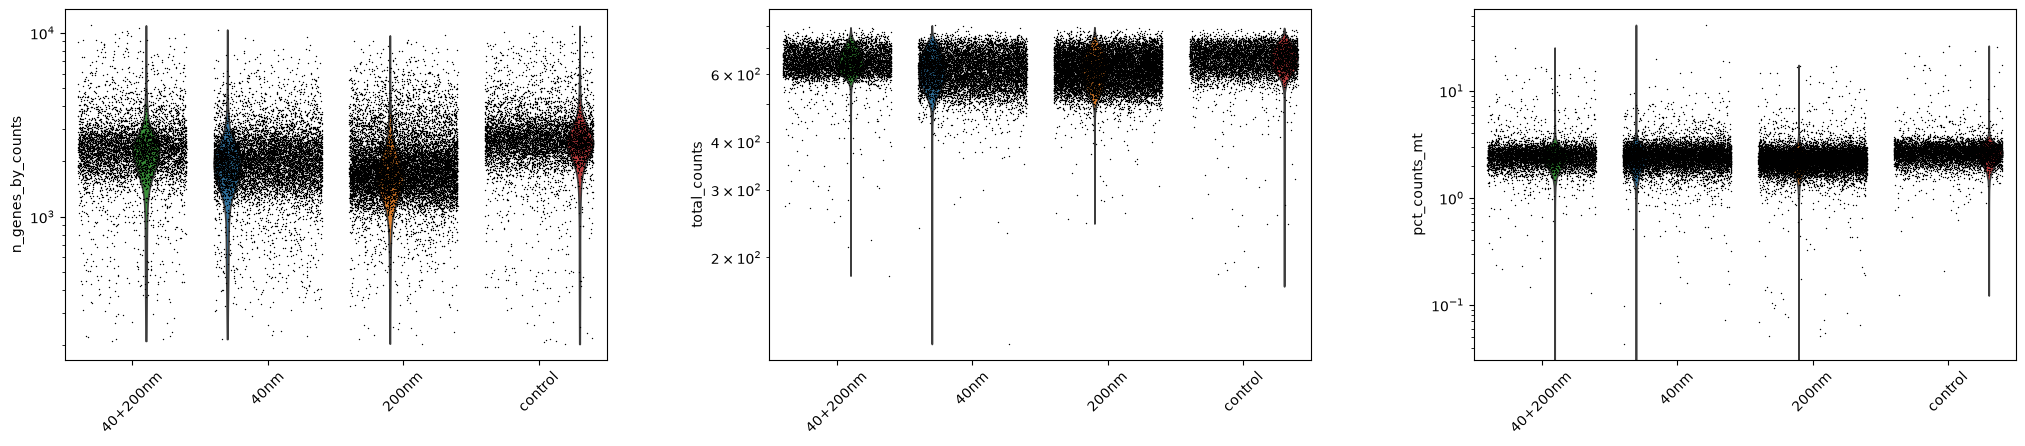

In [3]:
# Read H5AD file
adata = load_all_samples()

print(f"Is index unique? {adata.obs.index.is_unique}")

adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print('Columns in adata.obs:', adata.obs.columns.tolist())

# Calculate QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True, show=False, groupby='sample_id', rotation=45, log=True)
plt.savefig('results/qc_scatter.png')

In [4]:
# Calculate how many cells each gene appears in
gene_occurrence = (adata.X > 0).sum(axis=0)
if hasattr(gene_occurrence, 'A1'): gene_occurrence = gene_occurrence.A1

import pandas as pd
# Create a frequency table for the first 10 values
counts = pd.Series(gene_occurrence).value_counts().sort_index().head(10)

print("Number of cells | Number of genes found in exactly that many cells")
print("----------------|-----------------------------------------------")
print(counts)

Number of cells | Number of genes found in exactly that many cells
----------------|-----------------------------------------------
3     754
4     321
5     171
6     290
7     261
8     195
9     203
10    180
11    159
12    160
Name: count, dtype: int64


In [5]:
adata = filter_data(adata, 500, 5000, 5)

Stats BEFORE filtering: 34078 cells, 24380 genes
Stats AFTER filtering: 32757 cells, 24380 genes
